In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [3]:
Main.eval("""
    @everywhere begin
          
        using DelimitedFiles
        
        Grid1 = readdlm("../Grid/Γoverμ_1.csv", ',')
        Grid2 = readdlm("../Grid/Γoverμ_2.csv", ',')
        Grid3 = readdlm("../Grid/Γoverμ_3.csv", ',')
        Grid4 = readdlm("../Grid/Γoverμ_4.csv", ',')

        lnGrid1 = readdlm("../Grid/lnΓoverμ_1.csv", ',')
        lnGrid2 = readdlm("../Grid/lnΓoverμ_2.csv", ',')
        lnGrid3 = readdlm("../Grid/lnΓoverμ_3.csv", ',')
        lnGrid4 = readdlm("../Grid/lnΓoverμ_4.csv", ',')
          
        α1Grid = readdlm("../Grid/α1overμ.csv", ',')
        α2Grid = readdlm("../Grid/α2overμ.csv", ',')
        α3Grid = readdlm("../Grid/α3overμ.csv", ',')
        α4Grid = readdlm("../Grid/α4overμ.csv", ',')  
          
    end      
""")
Main.include("../Grid\\interpolation.jl")

Main.include("../strong coupling\\constants.jl")
Main.include("../strong coupling\\alpha_s.jl")
Main.include("../anomalous dim\\cusp\\cusp.jl")
Main.include("../anomalous dim\\non-cusp\\gammaH.jl")
Main.include("../anomalous dim\\non-cusp\\gammaB.jl")
Main.include("../anomalous dim\\non-cusp\\gammaS.jl")
Main.include("../anomalous dim\\non-cusp\\gammav.jl")
Main.include("../hard\\hard.jl")
Main.include("../jet\\jet.jl")
Main.include("../soft\\soft.jl")
Main.include("../sigma.jl")
Main.include("../error.jl")
Main.include("../fixed order\\perturbation.jl")
Main.include("../fixed order\\SCET.jl")
Main.include("../fixed order\\non-singular.jl")
Main.include("../fit.jl")
Main.include("../NP.jl")
Main.include("../renormalon.jl")

<PyCall.jlwrap test_func>

In [82]:
χ_lower = 145
χ_upper = 175

In [ ]:
optimal_params = [0.1173,  0.171, -0.450,  0.0981]
NLL="N3LL"
χ_low = 115
χ_up = 175
if_renormalon = False

In [83]:
#-------------------------------------------------------------------
dataset_names = ["SLD","TOPAZ_595","TOPAZ_533",
                 "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------


dataset_qua = ["OPAL","MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","DELPHI","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

df = df_qua
df.update(df_ss)

df_truncated = {}
χ = {}
EEC = {}
ERROR = {}

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0

In [84]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

In [85]:
import sys
def objective(params, df, Q_list, dataset_names, if_renormalon):

    #----------
    XLL = NLL
    XLO = 2 # 1:LO 2:NLO
    #----------

    N = 5
    chi2 = 0
    length = 0
    
    αs = params[0]
    params_noαs = params[1:]

    for name in dataset_names:

        xlist={}
        xlist_mid=np.array(df[name]["CHI"])
        binsize=abs(xlist_mid[1]-xlist_mid[0]) # Evenly sized bins assumed
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/4

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        l = len(xlist_mid)
        length = length + l

        PRED={}

        if if_renormalon:
            Ω1 = params_noαs[0]
            parameters = params_noαs[1:]
            if len(parameters)> 0:
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, parameters=parameters, Ω1=Ω1)
                DELTA =  DELTA_func(ylist,PRED)
            else: 
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, Ω1=Ω1)              
                DELTA =  DELTA_func(ylist,PRED)               
        else:
            parameters = params_noαs
            if len(parameters) > 0:
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO, parameters=parameters)                
                DELTA =  DELTA_func(ylist,PRED)             
            else: 
                for quartile in range(N):
                    PRED[quartile] = Main.model(xlist=xlist[quartile], αs=αs, Q=Q_list[name], XLL=XLL, XLO=XLO)              
                DELTA =  DELTA_func(ylist,PRED)              

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/length

Test

In [86]:
objective([0.1186,0.148,-0.322,0.232], df_truncated, Q_list, dataset_names, False)

1.0083810812467808

Import replicas 

In [90]:
result_set = {}
accuracies = ["fit_N3LL","scan_N3LL"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("result/"+XLL+".csv")

In [91]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set = {}
Ω1_set = {}
a_set = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    if if_renormalon == False:
        for i in range(cols):
            a_list[i] = params[:,i]
    if if_renormalon == True:
        Ω1_array = params[:,0]
        Ω1_set[XLL] = Ω1_array
        for i in range(cols-1):
            a_list[i] = params[:,i+1]
            
    a_set[XLL] = a_list

    #print(a_list)

In [92]:
#print(N_params)
#print(N_replicas)
params_replicas={}
for XLL in accuracies:
    N_params = len(a_set[XLL])
    N_replicas = len(a_set[XLL][0])
    params_reps = []
    for i in range(N_replicas):
        params = []
        for j in range(N_params):
            value = a_set[XLL][j][i]
            params.append(value)
        params_reps.append(params)
    params_replicas[XLL]=params_reps

In [36]:
#display(params_replicas)

Calculate bands

In [93]:
xlist = np.pi/180*np.linspace(χ_low, χ_up, 50, endpoint=True)
length=len(xlist)

EEC_replicas = {}
for XLL in accuracies:
    i=0
    EEC_reps = []
    for params in tqdm(params_replicas):
        #print(params) 
        EEC = {}
        for name in dataset_names:       
            v = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs_set[XLL][i], nf=5, XLL=NLL, parameters=params)
            non_singular=[]
            for x in xlist:
                non_singular.append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.1876, αs_ini=αs_set[XLL][i], nf=5, order=2))   
            EEC[name] = np.array(v) + np.array(non_singular)                
        EEC_reps.append(EEC)
        i = i+1
    EEC_replicas[XLL] = EEC_reps

100%|██████████| 100/100 [01:23<00:00,  1.20it/s]


In [48]:
#display(EEC_replicas)

In [98]:
EEC_upper = {}
EEC_lower = {}
for name in dataset_names: 
    upper_band = []
    lower_band = []
    for i in range(length):
        compare_list = []
        for j in range(N_replicas):
            value = EEC_replicas[j][name][i]
            compare_list.append(value)
        upper_EEC = np.percentile(compare_list,100)
        upper_band.append(upper_EEC)
        lower_EEC =np.percentile(compare_list,0)
        lower_band.append(lower_EEC)
    EEC_upper[name]=upper_band
    EEC_lower[name]=lower_band    

In [99]:
display(np.array(EEC_upper["SLD"])-np.array(EEC_lower["SLD"]))

array([0.00278336, 0.00282755, 0.00287775, 0.00293648, 0.00299922,
       0.00306613, 0.0031375 , 0.00321362, 0.00329473, 0.00338116,
       0.00347977, 0.00358537, 0.00369747, 0.00381652, 0.00394291,
       0.00407706, 0.00421948, 0.00437068, 0.00453108, 0.00470121,
       0.00488161, 0.00507273, 0.00527497, 0.00548874, 0.00571433,
       0.00595178, 0.00620092, 0.00646132, 0.00673201, 0.00701126,
       0.00729638, 0.0075834 , 0.00786637, 0.00817648, 0.00850657,
       0.00886107, 0.0092216 , 0.00955431, 0.00983208, 0.0100133 ,
       0.01003402, 0.00979578, 0.00937746, 0.00909253, 0.0107886 ,
       0.01556894, 0.02170654, 0.02739933, 0.0368169 , 0.0458738 ])

Calculate central

In [100]:
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]
#print(params_noαs)

v={}
non_singular = {}

for name in dataset_names:
    
    parameters = params_noαs

    v[name] = Main.sigma_fast(Q=Q_list[name], χ_list=xlist, μ_ini=91.1876, αs_ini=αs, nf=5, XLL=NLL, parameters=parameters)
    
    non_singular[name] = []
    for x in xlist:
        non_singular[name].append(Main.non_singular_sigma_χ(χ=x, Q=Q_list[name], μ_ini=91.1876, αs_ini=αs, nf=5, order=2))

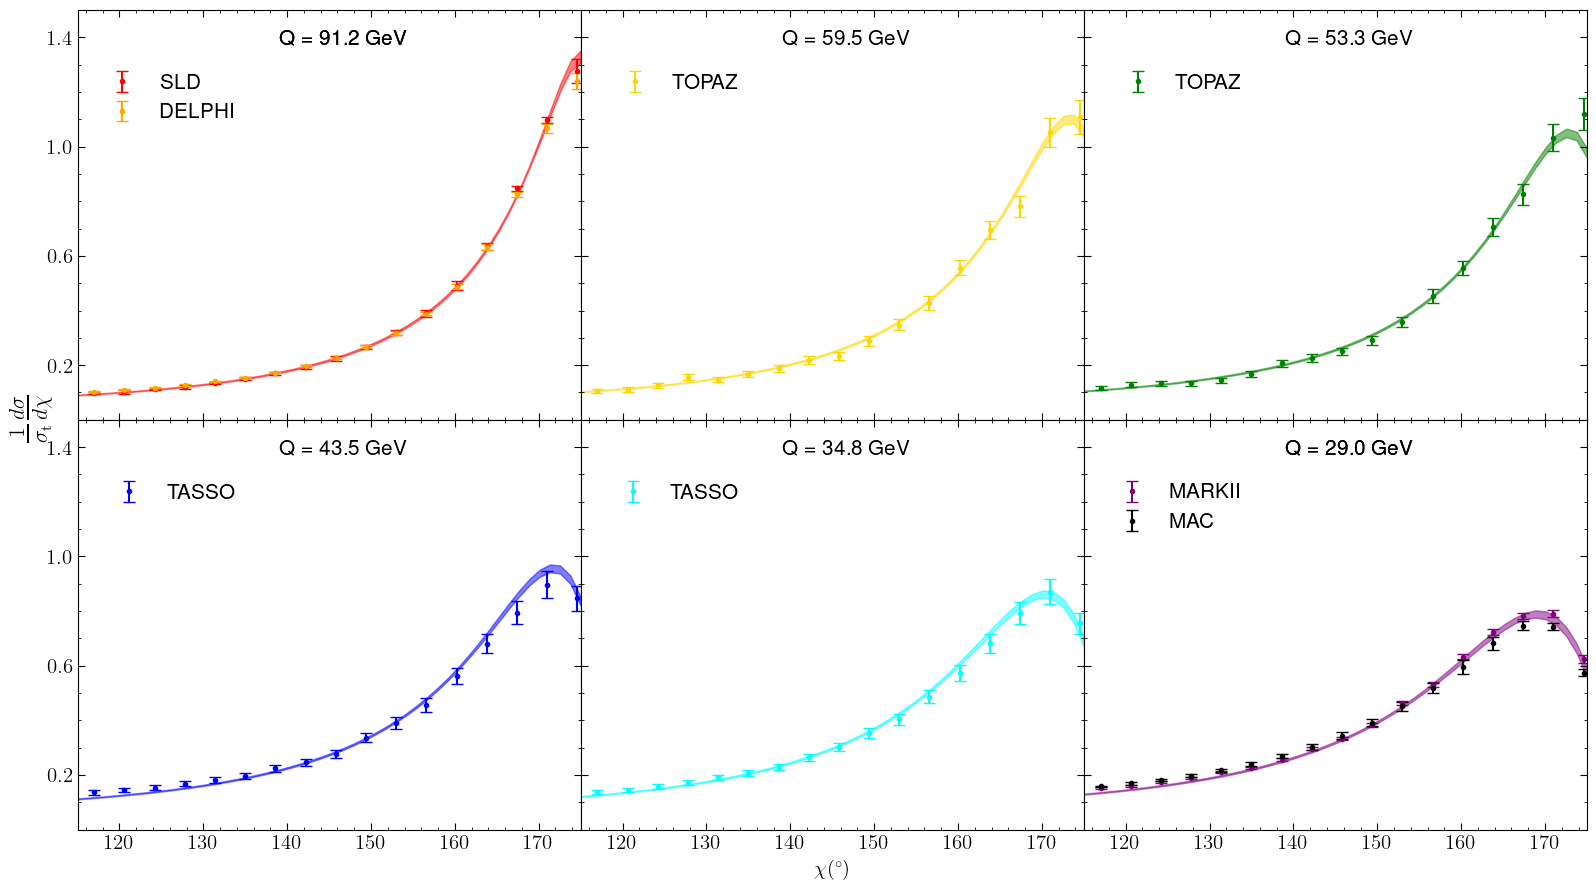

In [101]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True, sharey=True)
ax1, ax2, ax3, ax4, ax5, ax6 = axes.ravel()

sizeOfFont = 15
sizeOfTick = 15
props = dict(boxstyle='round', facecolor='white', alpha=0)

color = ["red","orange","gold","green","blue","cyan","purple","black"]
ax_list = [ax1,ax2,ax3,ax4,ax5,ax6]
Q_set = [91.2,59.5,53.3,43.5,34.8,29.0]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"

i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o',label=str(name_set[name]), color=color[j], capsize=4,markersize=3)
            ax_list[i].text(0.4, 0.95, "Q = " + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
            j=j+1
    i=i+1

color_band=["red","gold","green","blue","cyan","purple"]
names_band=["SLD","TOPAZ_595","TOPAZ_533",
                 "TASSO_435","TASSO_348","MARKII",]

i=0
j=0
for Q in Q_set:
    for name in names_band:
        if Q_list[name]==Q:
            #ax_list[i].plot(xlist*180/np.pi, v[name]+non_singular[name], color=color[j])
            ax_list[i].fill_between(xlist*180/np.pi, EEC_upper[name], EEC_lower[name], alpha=0.5, color=color_band[j])
            j=j+1
    i=i+1

ax5.set_xlabel(r"\rm $\chi({^{\circ}})$",fontsize=sizeOfFont)
ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{d \sigma}{d \chi}$",fontsize=1.5*sizeOfFont)
ax1.yaxis.set_label_coords(-0.05,0.0)
for ax in ax_list:
    ax.legend()
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(0.35, 0.89))
    #ax.axvline(x=χ_upper)

#plt.ylim(0.0, 1.5)
#plt.yticks([0.2,0.6,1.0,1.4])
plt.ylim(0.0, 1.5)
plt.yticks([0.2,0.6,1.0,1.4])

#plt.xticks([150,160,170])
plt.xticks([120,130,140,150,160,170])
plt.xlim(χ_low,χ_up)

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)  
plt.show()